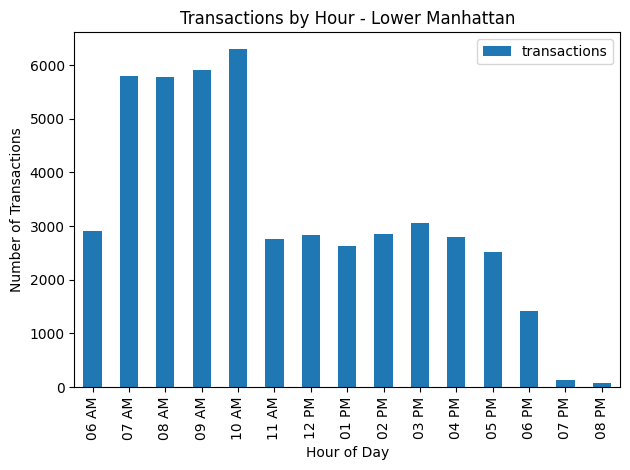

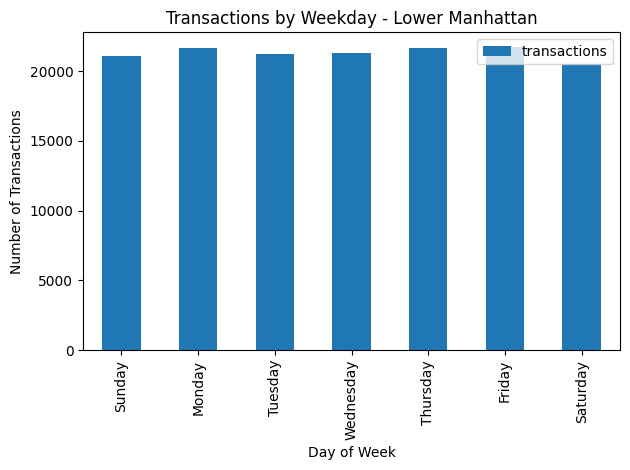

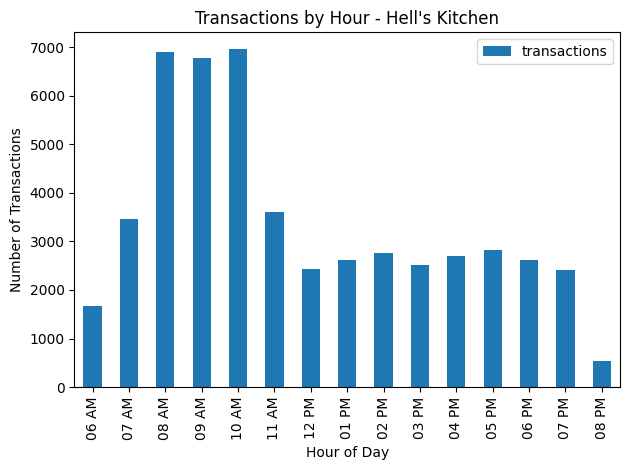

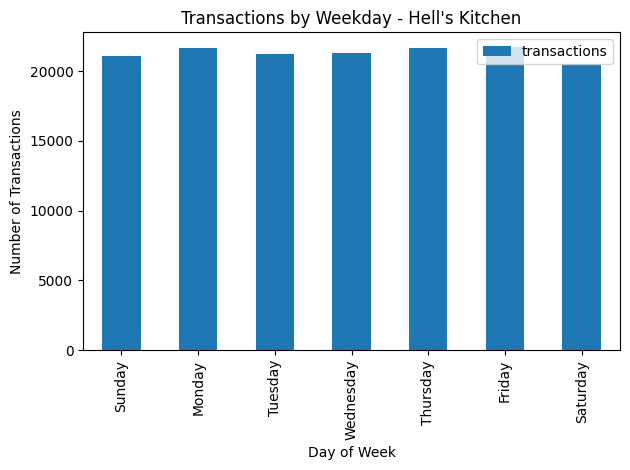

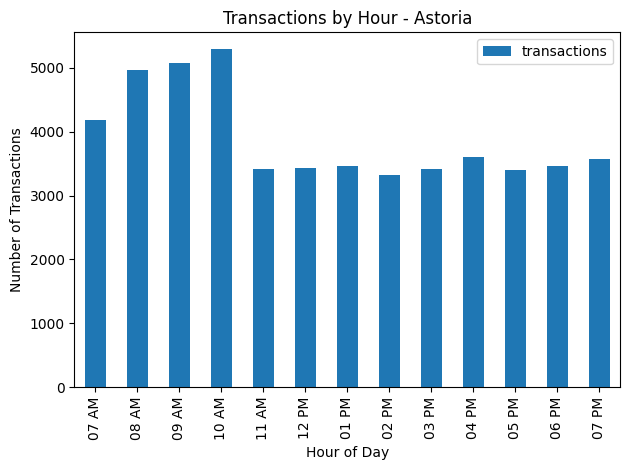

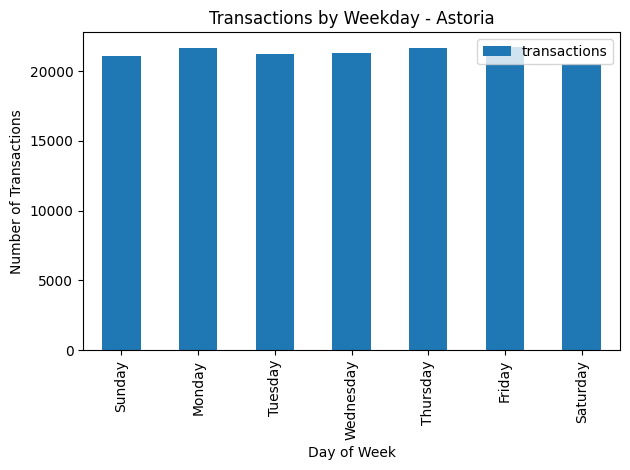

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/Coffee_shop_sales.xlsx")

df.head()

# Computing revenue (quantity * unit price)
df["revenue"] = df["transaction_qty"] * df["unit_price"]

#.to_datetime pandas library used to convert input types like strings into datetime objects

df["transaction_time"] = pd.to_datetime(
    df["transaction_time"].astype(str),
    format= "%H:%M:%S", 
    errors = "coerce"
)

# Drop any bad rows
df = df.dropna(subset=["transaction_time"])

# Extract hour from transaction_time
df["hour"] = df["transaction_time"].dt.hour

df["hour_label"] = df["transaction_time"].dt.strftime("%I %p")
# Group data by hour to analyze sales by time of day
hourly = df.groupby(["hour", "hour_label"])["revenue"].agg(["count","sum"]).reset_index()

hourly = hourly.rename(columns={
    "count": "transactions",
    "sum": "revenue"
})

# Get individual store data
store_locations = df["store_location"].unique()

for store in store_locations:
    store_df = df[df["store_location"] == store].copy()
    store_hourly = store_df.groupby(["hour", "hour_label"])["revenue"].agg(["count","sum"]).reset_index()
    store_hourly = store_hourly.rename(columns={
        "count": "transactions",
        "sum": "revenue"
    })


    # -- Visualizations for hourly data --
    # Bar chart for trasactions by hour
    store_hourly = store_hourly.sort_values("hour")

    store_hourly.plot( x = "hour_label", y = "transactions", kind= "bar")

    plt.title (f"Transactions by Hour - {store}")
    plt.xlabel ("Hour of Day")
    plt.ylabel ("Number of Transactions")

    # function in Matplotlib that fixes subplot parameters so it fits neatly

    plt.tight_layout()
    plt.show()

    #-- Busiest days of the week --
    df["transaction_date"] = pd.to_datetime(df["transaction_date"])
    df["weekday"] = df["transaction_date"].dt.day_name()

    weekday_sales = df.groupby("weekday")["revenue"].agg(["count", "sum"]).reset_index()

    weekday_sales = weekday_sales.rename(columns = {
        "count" : "transactions",
        "sum" : "revenue"
    
    })

    weekday_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

    weekday_sales["weekday"] = pd. Categorical (
        weekday_sales["weekday"],
        categories = weekday_order,
        ordered = True
    )
    weekday_sales = weekday_sales.sort_values("weekday")

    # -- Visualization for weekday data --

    weekday_sales.plot(x = "weekday", y = "transactions", kind = "bar")

    plt.title(f"Transactions by Weekday - {store}")
    plt.xlabel("Day of Week")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()




